In [6]:
using Pkg
Pkg.activate(".")
using IonSim
using QuantumOptics: timeevolution, expect, dm, normalize, dagger, ptrace
using Plots

  Activating project at `~/Documents/Projects/IonTrap`


In [7]:
# Single-Ion Setup
ca = Ca40([("S1/2", -1/2, "S"), ("D5/2", -1/2, "D")])
laser = Laser()
chain = LinearChain(ions = [ca], comfrequencies = (x=3e6, y=3e6, z=1e6), selectedmodes = (;z=[1]))
chamber = Chamber(iontrap = chain, B=4e-4, Bhat = ẑ, δB=0, lasers = [laser])
wavelength_from_transition!(laser, ca, ("S", "D"), chamber)
polarization!(laser, (x̂-ẑ)/√2)
wavevector!(laser, (x̂+ẑ)/√2)

τ_π = 2e-6 
intensity_from_pitime!(laser, τ_π, ca, ("S", "D"), chamber)
Ω= π/(τ_π * 1e6) 

mode = modes(chamber)[1]

VibrationalMode(ν=1.0e6, axis=ẑ, N=10)

In [8]:
# Gate: Carrier Pulse as a Function

# Have to set detuning! and phase! before hamiltonian as it bakes in the values
function carrier_pulse(ψ,θ, ϕ)
    detuning!(laser, 0)
    phase!(laser, ϕ)
    h = hamiltonian(chamber, timescale = 1e-6)
    t_pulse = θ/Ω
    _, sol = timeevolution.schroedinger_dynamic(range(0, t_pulse, length = 51), ψ, h) 
    return sol[end]

end

# Named gates:
X(ψ) = carrier_pulse(ψ, π, 0.0)
Y(ψ) = carrier_pulse(ψ, π, π/2)
sqrtX(ψ) = carrier_pulse(ψ, π/2, 0.0)

# Population Measurement
P_D(ψ) = real(expect(ionprojector(chamber, "D"), ψ))

P_D (generic function with 1 method)

In [9]:
# Validation

ψ0  = ca["S"] ⊗ mode[0]
println("=== Single-Qubit Gate Validation ===")

ψ_X = X(ψ0)
println("X|S>:  P(D) = ", round(P_D(ψ_X), digits=4), " (expected: 1.0)")
ψ_sx = sqrtX(ψ0)
println("√X|S>:  P(D) = ", round(P_D(ψ_sx), digits=4), " (expected: 0.5)")
ψ_sxsx = sqrtX(sqrtX(ψ0))
println("√X⋅√X|S>:  P(D) = ", round(P_D(ψ_sxsx), digits=4), " (expected: 1.0 - Two Half-Pulses = X)")
ψ_Y = Y(ψ0)
println("Y|S>:  P(D) = ", round(P_D(ψ_Y), digits=4), " (expected: 1.0)")
ψ_XX = X(X(ψ0))
println("X⋅X|S>:  P(D) = ", round(P_D(ψ_XX), digits=4), " (expected: 0.0 - X^2 = Identity)")


=== Single-Qubit Gate Validation ===
X|S>:  P(D) = 0.9997 (expected: 1.0)
√X|S>:  P(D) = 0.4979 (expected: 0.5)
√X⋅√X|S>:  P(D) = 0.9997 (expected: 1.0 - Two Half-Pulses = X)
Y|S>:  P(D) = 0.9997 (expected: 1.0)
X⋅X|S>:  P(D) = 0.0001 (expected: 0.0 - X^2 = Identity)


Ramsey Contrast 0.9993 (expected: 1.0)
Max deviation from analytic: 0.0004 (expected: 0.0)


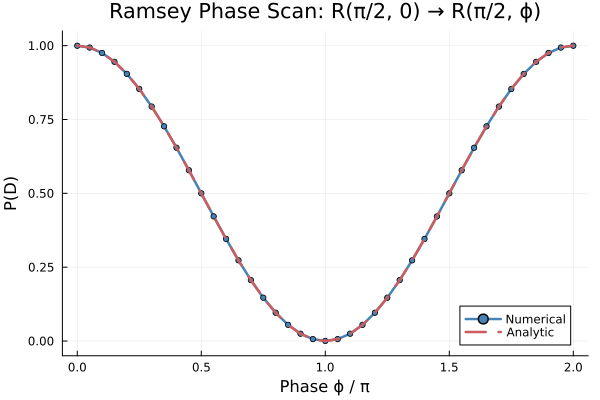

In [15]:
# Ramsey Phase Scan - To prove axis control
# Sequence: R(π/2, 0) → R(π/2, ϕ). Expect P(D) = cos²(ϕ/2)

ϕ_scan = range(0, 2π, length = 41)
ramsey = Float64[]
for ϕ in ϕ_scan
    ψ= carrier_pulse(ψ0, π/2, 0.0)
    ψ= carrier_pulse(ψ, π/2, ϕ)
    push!(ramsey, P_D(ψ))
end

analytic_ramsey = cos.(ϕ_scan ./ 2).^2

println("Ramsey Contrast ", round(maximum(ramsey) - minimum(ramsey), digits=4), " (expected: 1.0)")
println("Max deviation from analytic: ", round(maximum(abs.(ramsey - analytic_ramsey)), digits=4), " (expected: 0.0)")

plot(ϕ_scan ./ π, ramsey, label = "Numerical", color =:steelblue, lw=2.5, marker=:circle, markersize=3)
plot!(ϕ_scan ./ π, analytic_ramsey, label = "Analytic", color =:indianred, lw=2.5, ls=:dash)
xlabel!("Phase ϕ / π")
ylabel!("P(D)")
title!("Ramsey Phase Scan: R(π/2, 0) → R(π/2, ϕ)")
ylims!(-0.05, 1.05)